# 03 — Agrégation des CSV et analyse K-means

Ce notebook prend la suite du notebook `01_generer_csv.ipynb` pour un **K-means** : agrégation des fichiers CSV de métriques, nettoyage, imputation et standardisation des variables.

Les résultats produits sont sauvegardés dans `analysis/` :

- `features_for_kmeans.csv` : table agrégée, nettoyée et imputée utilisée pour le K-means ;
- `kmeans_clusters.csv` : affectation de chaque étudiant à un cluster ;
- `kmeans_cluster_centers_scaled.csv` : centres des clusters sur variables standardisées ;
- `kmeans_cluster_centers_original_units.csv` : centres des clusters dans les unités originales des métriques ;
- `kmeans_model_selection.csv` : inertie et silhouette pour plusieurs valeurs de `k`.


## 1. Configuration

Les paramètres importants sont regroupés ici. Les options `JOIN_MODE`, `IMPUTATION`, `MIN_NON_NULL_FEATURES` et `DROP_FEATURES` sont conservées comme dans le notebook ACP.


In [13]:
from pathlib import Path
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def detect_project_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "Chaine",
        Path.cwd() / "chaine_extracted" / "Chaine",
        Path.cwd().parent / "Chaine",
    ]
    for candidate in candidates:
        if (candidate / "csv").exists() and (
            (candidate / "data" / "MainTable.csv").exists() or (candidate / "scripts").exists()
        ):
            return candidate.resolve()
    raise FileNotFoundError(
        "Impossible de détecter automatiquement le dossier Chaine. "
        "Modifiez PROJECT_DIR manuellement dans cette cellule."
    )

# Par défaut, le notebook détecte automatiquement le dossier projet.
# PROJECT_DIR = Path(r"C:/Users/.../Chaine")
PROJECT_DIR = detect_project_dir()

CSV_DIR = PROJECT_DIR / "csv"
ANALYSIS_DIR = PROJECT_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Agrégation des métriques.
# "outer" garde tous les étudiants même présents dans un seul fichier et impute les valeurs manquantes.
# "inner" garde seulement les étudiants présents dans tous les fichiers.
JOIN_MODE = "outer"  # "outer" ou "inner"

# Imputation des valeurs manquantes avant le K-means : "median", "mean" ou "drop_rows".
IMPUTATION = "median"

# Nombre minimal de variables non nulles pour conserver un étudiant avant imputation.
MIN_NON_NULL_FEATURES = 2

# Colonnes variables à exclure explicitement du K-means, si besoin.
DROP_FEATURES = []

# Paramètres K-means.
N_CLUSTERS = 4
K_RANGE = range(2, 9)  # valeurs testées pour le graphique coude/silhouette
RANDOM_STATE = 42
N_INIT = 20

# Nombre de variables à afficher dans le profil des clusters.
TOP_N_PROFILE_VARIABLES = 12

print("Projet :", PROJECT_DIR)
print("Dossier CSV :", CSV_DIR)
print("Dossier analyse :", ANALYSIS_DIR)
print("Nombre de clusters choisi :", N_CLUSTERS)


Projet : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine
Dossier CSV : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\csv
Dossier analyse : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\analysis
Nombre de clusters choisi : 4


## 2. Chargement et agrégation des fichiers CSV

On charge uniquement les fichiers CSV qui contiennent une colonne `SubjectID`. Les fichiers de suivi comme `run_report.csv` sont ignorés.


In [14]:
if not CSV_DIR.exists():
    raise FileNotFoundError(f"Dossier CSV introuvable : {CSV_DIR}")

csv_paths = sorted(CSV_DIR.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"Aucun fichier CSV trouvé dans : {CSV_DIR}")

tables = []
inventory = []

for path in csv_paths:
    # Fichiers à ignorer.
    if path.name.lower() in {"run_report.csv", "stats.csv"}:
        inventory.append({
            "fichier": path.name,
            "statut": "ignoré",
            "raison": "fichier de rapport/statistiques, pas une métrique SubjectID",
            "lignes": None,
            "colonnes": None,
        })
        continue

    try:
        df = pd.read_csv(path)
    except Exception as exc:
        inventory.append({
            "fichier": path.name,
            "statut": "ignoré",
            "raison": f"lecture impossible : {exc}",
            "lignes": None,
            "colonnes": None,
        })
        continue

    if "SubjectID" not in df.columns:
        inventory.append({
            "fichier": path.name,
            "statut": "ignoré",
            "raison": "pas de colonne SubjectID",
            "lignes": df.shape[0],
            "colonnes": df.shape[1],
        })
        continue

    # Éviter les doublons éventuels par SubjectID dans un même fichier.
    df = df.drop_duplicates(subset=["SubjectID"], keep="first")

    # Préfixe en cas de collision de noms de variables entre fichiers.
    feature_cols = [c for c in df.columns if c != "SubjectID"]
    renamed = {}
    for c in feature_cols:
        if c in {"rows", "columns", "status"}:
            renamed[c] = f"{path.stem}_{c}"
    if renamed:
        df = df.rename(columns=renamed)

    tables.append(df)

    inventory.append({
        "fichier": path.name,
        "statut": "chargé",
        "raison": "",
        "lignes": df.shape[0],
        "colonnes": df.shape[1],
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

if not tables:
    raise ValueError("Aucun CSV de métrique exploitable n'a été trouvé.")

features = reduce(lambda left, right: pd.merge(left, right, on="SubjectID", how=JOIN_MODE), tables)
print(f"Table agrégée : {features.shape[0]:,} sujets × {features.shape[1]-1:,} variables")
display(features.head())


,fichier,statut,raison,lignes,colonnes
0,CompileCount.csv,chargé,,131,2
1,CompileSpan.csv,chargé,,110,2
2,CompileSuccessRate.csv,chargé,,131,2
3,ErrorQuotient.csv,chargé,,110,2
4,FirstCompileVsGlobalFirst.csv,chargé,,110,2
5,FracLong.csv,chargé,,121,2
6,LastCompileVsGlobalLast.csv,chargé,,110,2
7,MeanTestScore.csv,chargé,,131,2
8,RED.csv,chargé,,110,2
9,SessionCount.csv,chargé,,131,2


Table agrégée : 131 sujets × 11 variables


,SubjectID,CompileCount,CompileSpanMinutes,CompileSuccessRate,ErrorQuotient,MinutesFromGlobalFirstCompile,FracLong,MinutesToGlobalLastCompile,MeanTestScore,RED,SessionCount,MinutesToScore1
0,0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...,4,5.683333,1.000000,0.000000,12.366667,0.000000,40.516667,0.956522,0.000000,1,0.000000
1,07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...,1,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,1,NaN
2,080e819b7f2ec7fdf5df10abc0092a6ae39db49584244e...,5,4.566667,0.200000,0.750000,10.216667,0.000000,43.783333,0.200000,0.562500,1,4.566667
3,091dc109aa58c7a670f4b61bc23df548fec73c05c7582d...,29,45.600000,0.896552,0.045455,5.916667,0.107143,7.050000,0.873358,0.022727,4,1.150000
4,0973288c77f97c9245c444f90526bc6137bc40b4820019...,16,27.183333,0.812500,0.125000,11.300000,0.000000,20.083333,0.745722,0.062500,1,3.133333


## 3. Nettoyage de la table pour le K-means

Seules les variables numériques sont conservées. Les variables constantes sont supprimées, car elles n’aident pas à former des clusters.


In [15]:
features = features.copy()

# Conversion prudente des colonnes en numérique quand c'est possible.
for col in features.columns:
    if col != "SubjectID":
        features[col] = pd.to_numeric(features[col], errors="coerce")

# Exclusions manuelles.
drop_manual = [c for c in DROP_FEATURES if c in features.columns]
if drop_manual:
    features = features.drop(columns=drop_manual)

numeric_cols = [
    c for c in features.columns
    if c != "SubjectID" and pd.api.types.is_numeric_dtype(features[c])
]

X_raw = features[["SubjectID", *numeric_cols]].copy()

# Supprimer les étudiants avec trop peu de variables observées.
non_null_counts = X_raw[numeric_cols].notna().sum(axis=1)
X_raw = X_raw.loc[non_null_counts >= MIN_NON_NULL_FEATURES].reset_index(drop=True)

# Supprimer les variables entièrement vides ou constantes.
usable_cols = []
removed_cols = []
for col in numeric_cols:
    series = X_raw[col]
    if series.notna().sum() == 0:
        removed_cols.append((col, "entièrement vide"))
    elif series.nunique(dropna=True) <= 1:
        removed_cols.append((col, "constante"))
    else:
        usable_cols.append(col)

X_raw = X_raw[["SubjectID", *usable_cols]].copy()

print(f"Sujets conservés : {X_raw.shape[0]:,}")
print(f"Variables conservées : {len(usable_cols):,}")
if removed_cols:
    display(pd.DataFrame(removed_cols, columns=["variable", "raison_suppression"]))

missing_summary = (
    X_raw[usable_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("pct_valeurs_manquantes")
    .reset_index()
    .rename(columns={"index": "variable"})
)
display(missing_summary)


Sujets conservés : 131
Variables conservées : 11


,variable,pct_valeurs_manquantes
0,CompileSpanMinutes,16.030534
1,MinutesFromGlobalFirstCompile,16.030534
2,ErrorQuotient,16.030534
3,MinutesToScore1,16.030534
4,RED,16.030534
5,MinutesToGlobalLastCompile,16.030534
6,FracLong,7.633588
7,CompileSuccessRate,0.000000
8,CompileCount,0.000000
9,MeanTestScore,0.000000


## 4. Imputation et standardisation

Le K-means est sensible aux échelles des variables. On utilise donc les mêmes variables imputées, puis on les standardise avant d’appliquer l’algorithme.


In [16]:
if len(usable_cols) < 2:
    raise ValueError("Il faut au moins deux variables numériques non constantes pour réaliser un K-means.")

X_values = X_raw[usable_cols].copy()

if IMPUTATION == "drop_rows":
    keep_mask = X_values.notna().all(axis=1)
    X_raw_kmeans = X_raw.loc[keep_mask].reset_index(drop=True)
    X_values = X_raw_kmeans[usable_cols].copy()
else:
    strategy = {"median": "median", "mean": "mean"}.get(IMPUTATION)
    if strategy is None:
        raise ValueError("IMPUTATION doit valoir 'median', 'mean' ou 'drop_rows'.")
    imputer = SimpleImputer(strategy=strategy)
    X_imputed = imputer.fit_transform(X_values)
    X_values = pd.DataFrame(X_imputed, columns=usable_cols)
    X_raw_kmeans = X_raw.copy()

if X_values.shape[0] < 2:
    raise ValueError("Il faut au moins deux sujets pour lancer un K-means.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

features_for_kmeans = pd.concat(
    [X_raw_kmeans[["SubjectID"]].reset_index(drop=True), X_values.reset_index(drop=True)],
    axis=1
)
features_for_kmeans.to_csv(ANALYSIS_DIR / "features_for_kmeans.csv", index=False)

print(f"Table utilisée pour K-means : {features_for_kmeans.shape[0]:,} sujets × {len(usable_cols):,} variables")
display(features_for_kmeans.head())


Table utilisée pour K-means : 131 sujets × 11 variables


,SubjectID,CompileCount,CompileSpanMinutes,CompileSuccessRate,ErrorQuotient,MinutesFromGlobalFirstCompile,FracLong,MinutesToGlobalLastCompile,MeanTestScore,RED,SessionCount,MinutesToScore1
0,0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...,4.0,5.683333,1.000000,0.000000,12.366667,0.000000,40.516667,0.956522,0.000000,1.0,0.000000
1,07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...,1.0,26.900000,0.000000,0.333333,12.658333,0.071429,14.908333,0.000000,0.215839,1.0,4.458333
2,080e819b7f2ec7fdf5df10abc0092a6ae39db49584244e...,5.0,4.566667,0.200000,0.750000,10.216667,0.000000,43.783333,0.200000,0.562500,1.0,4.566667
3,091dc109aa58c7a670f4b61bc23df548fec73c05c7582d...,29.0,45.600000,0.896552,0.045455,5.916667,0.107143,7.050000,0.873358,0.022727,4.0,1.150000
4,0973288c77f97c9245c444f90526bc6137bc40b4820019...,16.0,27.183333,0.812500,0.125000,11.300000,0.000000,20.083333,0.745722,0.062500,1.0,3.133333


## 5. Choix simple du nombre de clusters

Cette cellule calcule deux indicateurs pour plusieurs valeurs de `k` :

- **inertie** : plus elle est faible, plus les points sont proches de leur centre de cluster ;
- **silhouette** : plus elle est élevée, plus les clusters sont séparés.

Le nombre réellement utilisé ensuite reste le paramètre `N_CLUSTERS` défini en configuration.


In [17]:
n_samples = X_scaled.shape[0]
valid_k_values = [k for k in K_RANGE if 2 <= k <= n_samples - 1]

if not valid_k_values:
    print("Pas assez de sujets pour calculer une silhouette sur plusieurs valeurs de k.")
    model_selection_df = pd.DataFrame(columns=["k", "inertia", "silhouette"])
else:
    rows = []
    for k in valid_k_values:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
        labels = km.fit_predict(X_scaled)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
        })

    model_selection_df = pd.DataFrame(rows)
    display(model_selection_df)

model_selection_df.to_csv(ANALYSIS_DIR / "kmeans_model_selection.csv", index=False)


,k,inertia,silhouette
0,2,1056.797579,0.240175
1,3,878.760606,0.216760
2,4,746.174429,0.219530
3,5,651.669326,0.228899
4,6,589.841409,0.236722
5,7,539.764995,0.248472
6,8,488.575757,0.271843


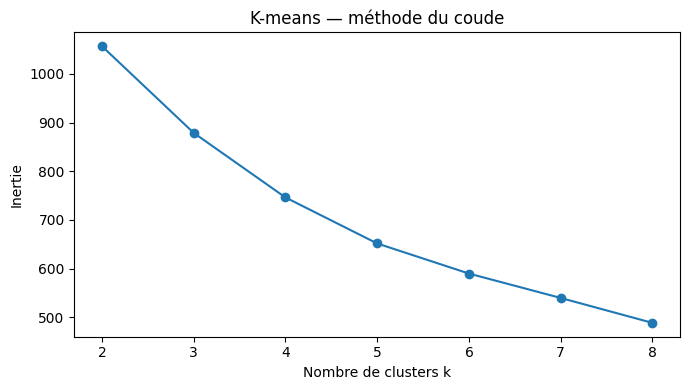

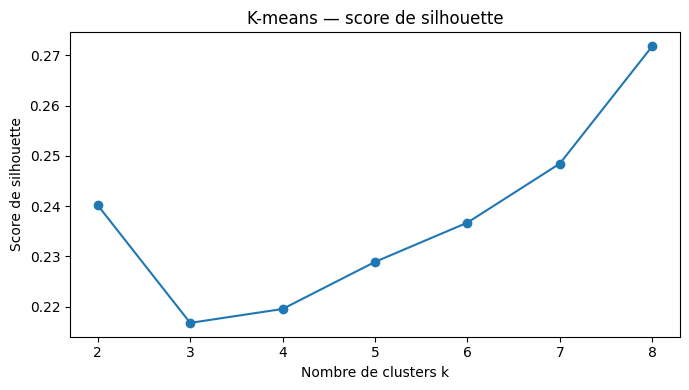

In [18]:
if not model_selection_df.empty:
    plt.figure(figsize=(7, 4))
    plt.plot(model_selection_df["k"], model_selection_df["inertia"], marker="o")
    plt.xlabel("Nombre de clusters k")
    plt.ylabel("Inertie")
    plt.title("K-means — méthode du coude")
    plt.xticks(model_selection_df["k"])
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(model_selection_df["k"], model_selection_df["silhouette"], marker="o")
    plt.xlabel("Nombre de clusters k")
    plt.ylabel("Score de silhouette")
    plt.title("K-means — score de silhouette")
    plt.xticks(model_selection_df["k"])
    plt.tight_layout()
    plt.show()
else:
    print("Graphiques de sélection de k non disponibles.")


## 6. K-means final

On applique le K-means avec `N_CLUSTERS`, puis on sauvegarde l’affectation des étudiants et les centres des clusters.


In [19]:
if not (2 <= N_CLUSTERS <= X_scaled.shape[0]):
    raise ValueError(f"N_CLUSTERS doit être compris entre 2 et le nombre de sujets ({X_scaled.shape[0]}).")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INIT)
labels = kmeans.fit_predict(X_scaled)
cluster_labels = labels + 1  # numérotation plus lisible : 1, 2, 3, ...

clusters_df = pd.DataFrame({
    "SubjectID": X_raw_kmeans["SubjectID"].values,
    "Cluster": cluster_labels,
})

features_with_clusters = features_for_kmeans.copy()
features_with_clusters.insert(1, "Cluster", cluster_labels)

centers_scaled_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=usable_cols,
    index=[f"Cluster {i}" for i in range(1, N_CLUSTERS + 1)]
)
centers_scaled_df.index.name = "Cluster"

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_original_df = pd.DataFrame(
    centers_original,
    columns=usable_cols,
    index=[f"Cluster {i}" for i in range(1, N_CLUSTERS + 1)]
)
centers_original_df.index.name = "Cluster"

cluster_summary_df = (
    clusters_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="n_sujets")
)
cluster_summary_df["pct_sujets"] = cluster_summary_df["n_sujets"] / cluster_summary_df["n_sujets"].sum() * 100

clusters_df.to_csv(ANALYSIS_DIR / "kmeans_clusters.csv", index=False)
features_with_clusters.to_csv(ANALYSIS_DIR / "features_with_kmeans_clusters.csv", index=False)
centers_scaled_df.to_csv(ANALYSIS_DIR / "kmeans_cluster_centers_scaled.csv")
centers_original_df.to_csv(ANALYSIS_DIR / "kmeans_cluster_centers_original_units.csv")
cluster_summary_df.to_csv(ANALYSIS_DIR / "kmeans_cluster_summary.csv", index=False)

print("Répartition des sujets par cluster")
display(cluster_summary_df)

print("Centres des clusters dans les unités originales")
display(centers_original_df)

print("Fichiers sauvegardés dans :", ANALYSIS_DIR)


Répartition des sujets par cluster


,Cluster,n_sujets,pct_sujets
0,1,38,29.007634
1,2,33,25.190840
2,3,20,15.267176
3,4,40,30.534351


Centres des clusters dans les unités originales


,CompileCount,CompileSpanMinutes,CompileSuccessRate,ErrorQuotient,MinutesFromGlobalFirstCompile,FracLong,MinutesToGlobalLastCompile,MeanTestScore,RED,SessionCount,MinutesToScore1
Cluster,,,,,,,,,,,
Cluster 1,8.921053,25.489474,0.838051,0.104389,12.918640,0.171800,19.403289,0.704862,0.062050,2.105263,3.450219
Cluster 2,26.030303,39.178283,0.520408,0.397466,11.510606,0.088413,7.877778,0.414998,0.311178,2.787879,7.498485
Cluster 3,10.800000,16.280833,0.091029,0.882793,17.291667,0.081239,24.994167,0.069335,0.740603,1.850000,52.459167
Cluster 4,6.375000,16.716250,0.356301,0.402635,13.913750,0.041573,26.501667,0.292089,0.271582,1.275000,5.967083


Fichiers sauvegardés dans : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\analysis


## 7. Taille des clusters


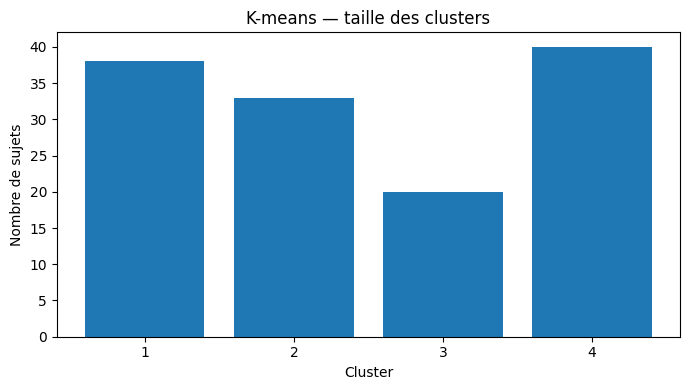

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(cluster_summary_df["Cluster"].astype(str), cluster_summary_df["n_sujets"])
plt.xlabel("Cluster")
plt.ylabel("Nombre de sujets")
plt.title("K-means — taille des clusters")
plt.tight_layout()
plt.show()


## 8. Profil simple des clusters

Les valeurs ci-dessous sont exprimées en variables standardisées. Une valeur positive signifie que le cluster est au-dessus de la moyenne globale pour cette métrique ; une valeur négative signifie qu’il est en dessous.


In [21]:
profile_rows = []
for cluster_name, row in centers_scaled_df.iterrows():
    tmp = row.abs().sort_values(ascending=False).head(TOP_N_PROFILE_VARIABLES)
    for variable in tmp.index:
        profile_rows.append({
            "Cluster": cluster_name,
            "variable": variable,
            "centre_standardise": row[variable],
            "sens": "au-dessus de la moyenne" if row[variable] > 0 else "en dessous de la moyenne",
        })

cluster_profile_df = pd.DataFrame(profile_rows)
cluster_profile_df.to_csv(ANALYSIS_DIR / "kmeans_cluster_profile.csv", index=False)
display(cluster_profile_df)


,Cluster,variable,centre_standardise,sens
0,Cluster 1,CompileSuccessRate,1.106556,au-dessus de la moyenne
1,Cluster 1,MeanTestScore,1.079501,au-dessus de la moyenne
2,Cluster 1,ErrorQuotient,-0.953734,en dessous de la moyenne
3,Cluster 1,RED,-0.887955,en dessous de la moyenne
4,Cluster 1,FracLong,0.637868,au-dessus de la moyenne
5,Cluster 1,MinutesToScore1,-0.471818,en dessous de la moyenne
6,Cluster 1,CompileCount,-0.360763,en dessous de la moyenne
7,Cluster 1,SessionCount,0.112650,au-dessus de la moyenne
8,Cluster 1,MinutesFromGlobalFirstCompile,-0.078125,en dessous de la moyenne
9,Cluster 1,CompileSpanMinutes,0.048652,au-dessus de la moyenne


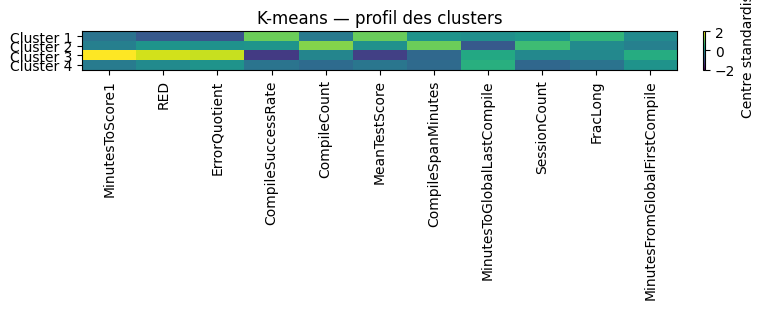

In [22]:
# Heatmap lisible : on affiche les variables qui différencient le plus les clusters.
if len(usable_cols) > 0:
    cols_to_plot = (
        centers_scaled_df
        .abs()
        .max(axis=0)
        .sort_values(ascending=False)
        .head(min(TOP_N_PROFILE_VARIABLES, len(usable_cols)))
        .index
        .tolist()
    )

    heatmap_data = centers_scaled_df[cols_to_plot]

    plt.figure(figsize=(max(8, 0.65 * len(cols_to_plot)), 1.2 + 0.5 * N_CLUSTERS))
    im = plt.imshow(heatmap_data, aspect="auto", vmin=-2, vmax=2)
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Centre standardisé")
    plt.xticks(range(len(cols_to_plot)), cols_to_plot, rotation=90)
    plt.yticks(range(N_CLUSTERS), heatmap_data.index)
    plt.title("K-means — profil des clusters")
    plt.tight_layout()
    plt.show()


## 9. Synthèse automatique à compléter

Cette synthèse donne une lecture rapide des clusters. Elle sert de point de départ, pas de conclusion définitive.


In [24]:
def format_cluster_profile(cluster_name, n=5):
    tmp = centers_scaled_df.loc[cluster_name].copy()
    tmp = tmp.reindex(tmp.abs().sort_values(ascending=False).head(n).index)
    parts = []
    for variable, value in tmp.items():
        sign = "+" if value >= 0 else "-"
        parts.append(f"{variable} ({sign}{abs(value):.2f})")
    return ", ".join(parts)

print("Synthèse K-means")
print("----------------")
print(f"Nombre de sujets inclus : {clusters_df.shape[0]}")
print(f"Nombre de variables incluses : {len(usable_cols)}")
print(f"Nombre de clusters choisi : {N_CLUSTERS}")
print()

for _, row in cluster_summary_df.iterrows():
    cluster_name = f"Cluster {int(row['Cluster'])}"
    print(f"{cluster_name} : {int(row['n_sujets'])} sujets ({row['pct_sujets']:.1f} %)")
    print("  Variables qui caractérisent le plus ce cluster :")
    print("  " + format_cluster_profile(cluster_name))
    print()


Synthèse K-means
----------------
Nombre de sujets inclus : 131
Nombre de variables incluses : 11
Nombre de clusters choisi : 4

Cluster 1 : 38 sujets (29.0 %)
  Variables qui caractérisent le plus ce cluster :
  CompileSuccessRate (+1.11), MeanTestScore (+1.08), ErrorQuotient (-0.95), RED (-0.89), FracLong (+0.64)

Cluster 2 : 33 sujets (25.2 %)
  Variables qui caractérisent le plus ce cluster :
  CompileCount (+1.26), CompileSpanMinutes (+1.10), MinutesToGlobalLastCompile (-0.89), SessionCount (+0.75), MinutesToScore1 (-0.27)

Cluster 3 : 20 sujets (15.3 %)
  Variables qui caractérisent le plus ce cluster :
  MinutesToScore1 (+2.02), RED (+1.73), ErrorQuotient (+1.66), CompileSuccessRate (-1.32), MeanTestScore (-1.24)

Cluster 4 : 40 sujets (30.5 %)
  Variables qui caractérisent le plus ce cluster :
  SessionCount (-0.66), CompileSpanMinutes (-0.62), CompileCount (-0.60), MinutesToGlobalLastCompile (+0.53), FracLong (-0.48)

